<a href="https://colab.research.google.com/github/sisodia91/data-analysis-tasks/blob/main/Task__2_Data_Cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from scipy import stats

In [2]:
df = pd.read_csv('/content/tested.csv')

In [3]:
print("Data Shape:", df.shape)
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())
print(df.describe(include='all'))

Data Shape: (418, 12)

Data Types:
 PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

Missing Values:
 PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64
        PassengerId    Survived      Pclass                      Name   Sex  \
count    418.000000  418.000000  418.000000                       418   418   
unique          NaN         NaN         NaN                       418     2   
top             NaN         NaN         NaN  Peter, Master. Michael J  male   
freq            NaN         NaN         NaN                         1   266   
mean    1100.500000 

In [4]:
df['Age'].fillna(df['Age'].median(), inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)
df.drop(columns=['Cabin'], inplace=True)


/tmp/ipykernel_958/224943107.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
/tmp/ipykernel_958/224943107.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try us

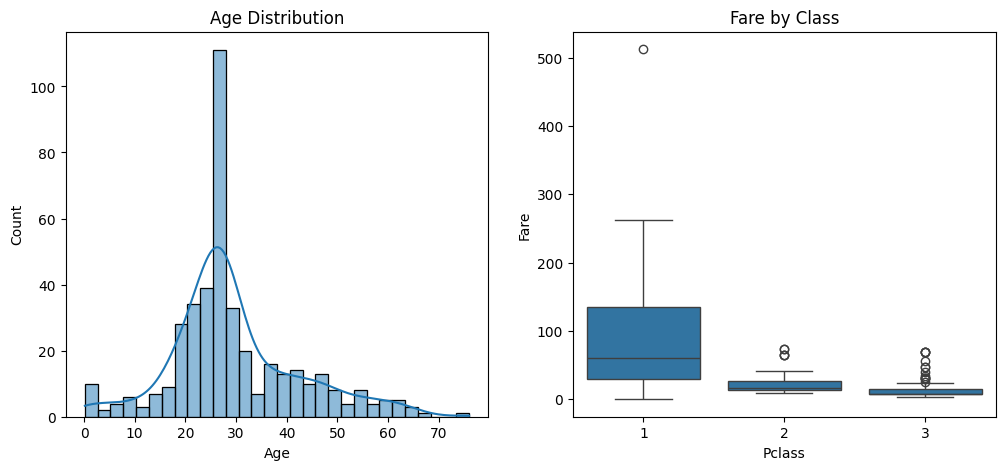

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(df['Age'], bins=30, kde=True, ax=ax[0])
ax[0].set_title('Age Distribution')

sns.boxplot(x='Pclass', y='Fare', data=df, ax=ax[1])
ax[1].set_title('Fare by Class')

plt.show()

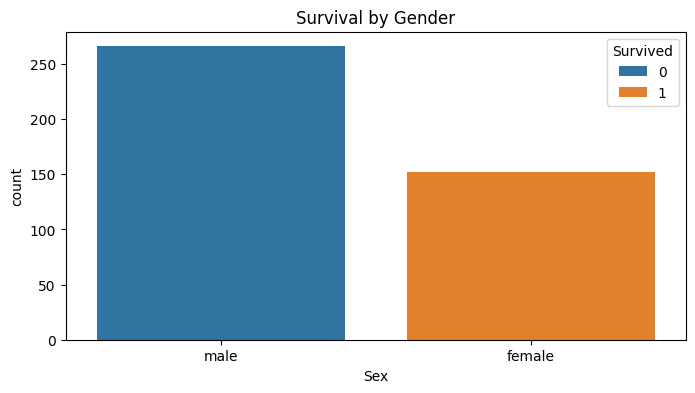

In [6]:
plt.figure(figsize=(8,4))

sns.countplot(x='Sex', hue='Survived', data=df)

plt.title('Survival by Gender')

plt.show()

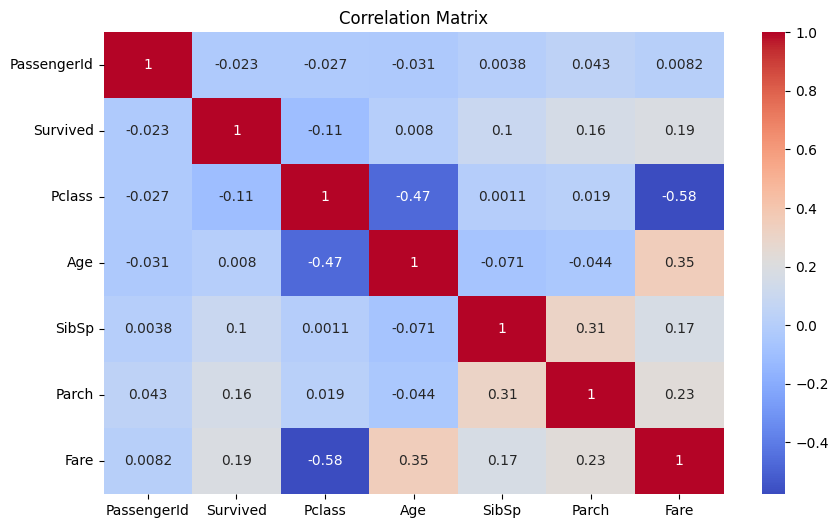

In [7]:
plt.figure(figsize=(10,6))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Matrix")

plt.show()

In [8]:
pd.crosstab(df['Pclass'],
            df['Survived'],
            normalize='index') * 100

Survived,0,1
Pclass,,
1,53.271028,46.728972
2,67.741935,32.258065
3,66.972477,33.027523


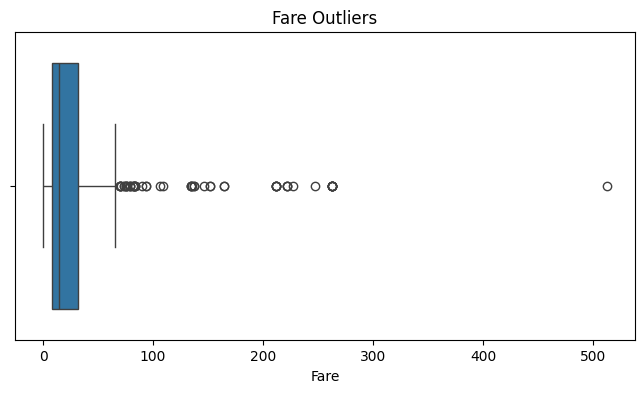

In [9]:
plt.figure(figsize=(8,4))

sns.boxplot(x=df['Fare'])

plt.title("Fare Outliers")

plt.show()

In [10]:
z_scores = np.abs(stats.zscore(df['Fare']))

outliers = df[z_scores > 3]

print("Found", len(outliers), "fare outliers")

Found 0 fare outliers


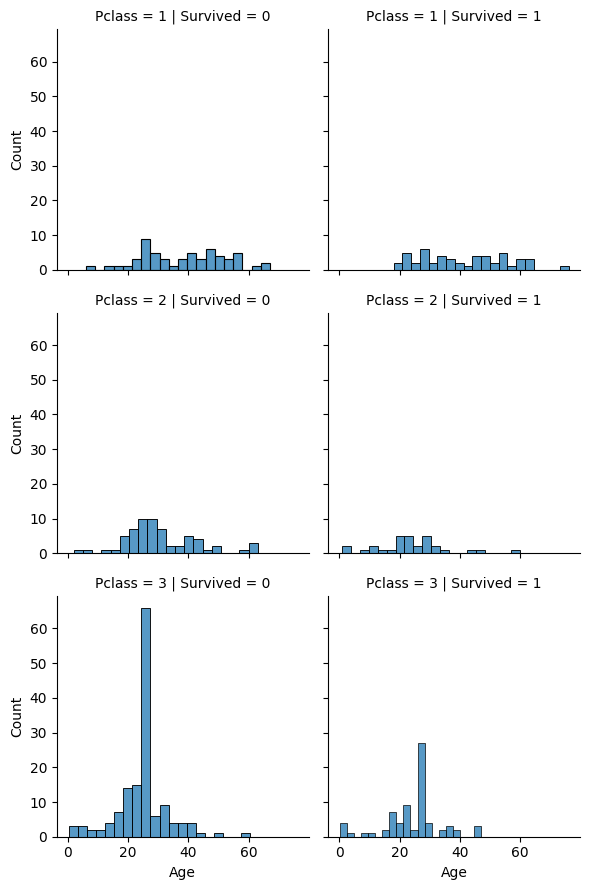

In [11]:
g = sns.FacetGrid(df,
                  col='Survived',
                  row='Pclass',
                  height=3)

g.map(sns.histplot, 'Age', bins=20)

plt.show()

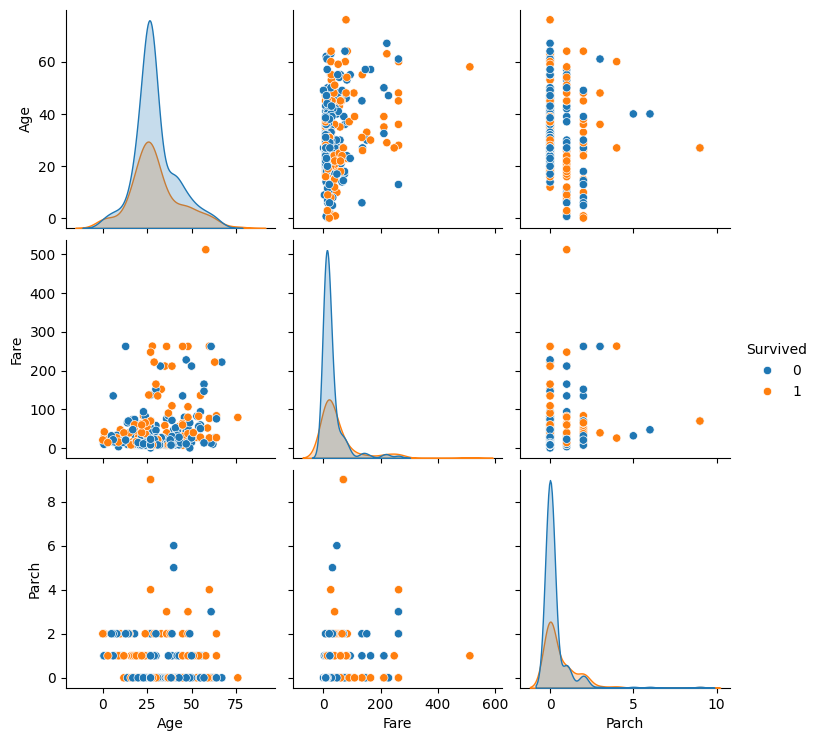

In [12]:
sns.pairplot(df[['Age',
                 'Fare',
                 'Parch',
                 'Survived']],
                 hue='Survived')

plt.show()